IMPORT LIBRARIES

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as ans
import numpy as np


In [ ]:
(x_train, y_train), (x_test, y_test)=tf.keras.datasets.cifar10.load_data()
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_test shape: {y_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [ ]:
num_classes = len(np.unique(y_train))
print("number of classes:",num_classes)
print("class labels:",np.unique(y_train))

number of classes: 10
class labels: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
x_test.shape

(10000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_test.shape

(10000, 1)

In [ ]:
print("shape of a single image(x_train[100]):",x_train[100].shape)

shape of a single image(x_train[100]): (32, 32, 3)


In [ ]:
x_train,x_test=x_train/255.0,x_test/255.0


In [ ]:
y_train=y_train.flatten()
y_test=y_test.flatten()


In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse','ship','truck']

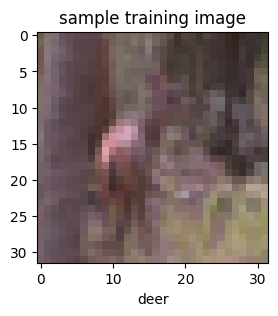

In [ ]:
def plot_sample(x,y,index):
  plt.figure(figsize=(3,3))
  plt.imshow(x[index])
  plt.xlabel(class_names[y[index]])
  plt.title("sample training image")
  plt.show()
plot_sample(x_train,y_train,399)


In [ ]:

import tensorflow as tf
from tensorflow.keras import layers

model=tf.keras.models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
    ])

In [ ]:
model.compile(optimizer="adam",
              loss = "sparse_categorical_crossentropy",
              metrics = ['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train, y_train,epochs=10,
                    validation_data=(x_test,y_test),batch_size = 64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.3329 - loss: 1.7907 - val_accuracy: 0.4748 - val_loss: 1.4610
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.4750 - loss: 1.4514 - val_accuracy: 0.5475 - val_loss: 1.2679
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.5340 - loss: 1.3070 - val_accuracy: 0.5861 - val_loss: 1.1516
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.5743 - loss: 1.2070 - val_accuracy: 0.6121 - val_loss: 1.0925
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.6007 - loss: 1.1408 - val_accuracy: 0.6494 - val_loss: 0.9839
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.6223 - loss: 1.0783 - val_accuracy: 0.6437 - val_loss: 0.9945
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.6436 - loss: 1.0244 - val_accuracy: 0.6729 - val_loss: 0.9282
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.6601 - loss: 0.9773 - 

In [ ]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("test accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6893 - loss: 0.8867
test accuracy: 0.689300000667572


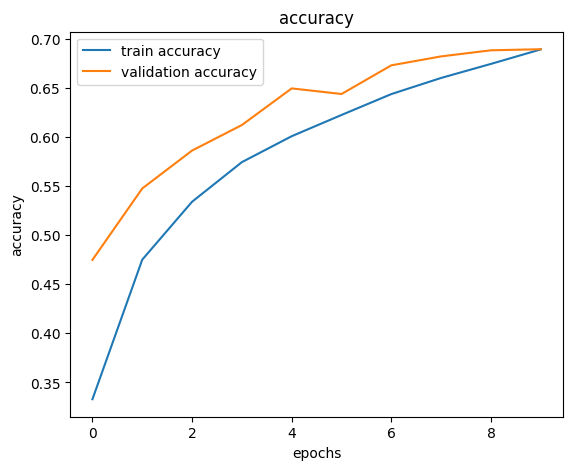

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

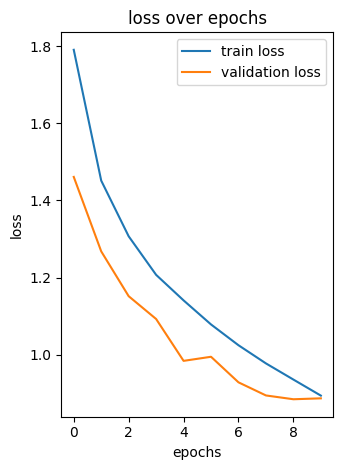

In [ ]:
import matplotlib.pyplot as plt
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.title('loss over epochs')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


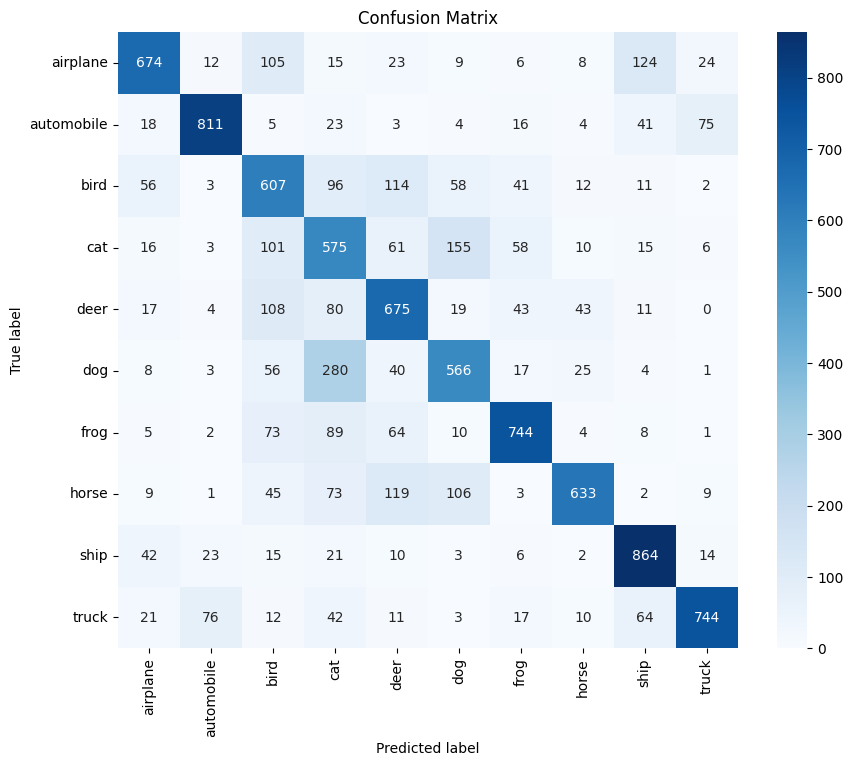

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
ans.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

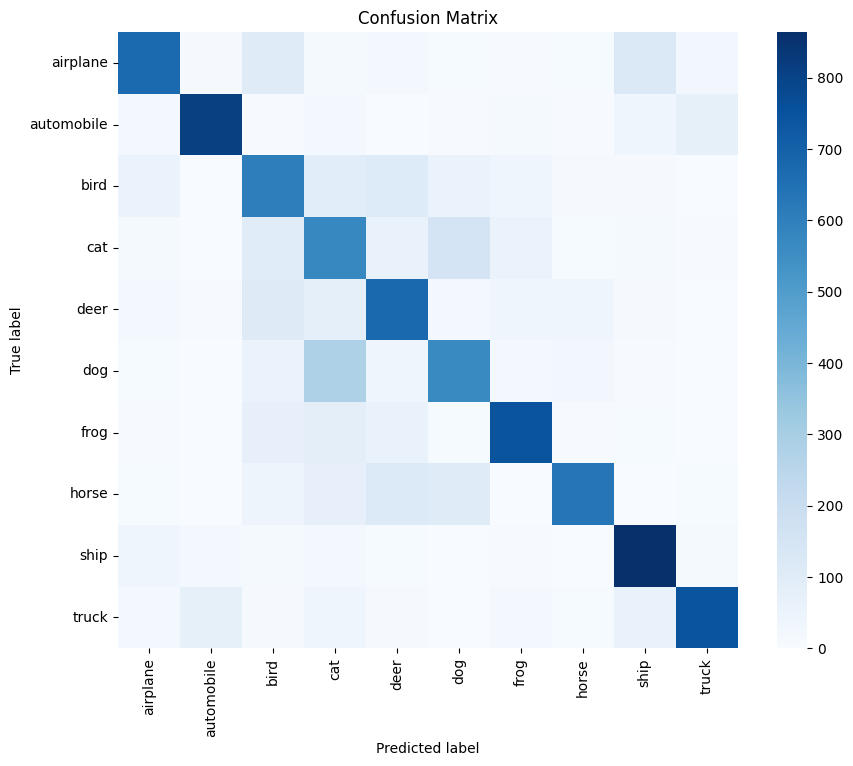

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
ans.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

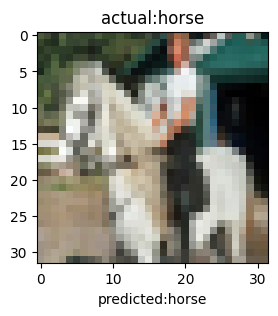

In [ ]:
index = 56
plt.figure(figsize=(3,3))
plt.imshow(x_test[index])
plt.title(f"actual:{class_names[y_test[index]]}")
plt.xlabel(f"predicted:{class_names[y_pred_classes[index]]}")
plt.show()